<a href="https://colab.research.google.com/github/vijiganesan018-dev/ML-LAB/blob/main/162MLEX6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import re
import nltk



In [6]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score
from sklearn.metrics import confusion_matrix,classification_report

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully")


Libraries imported successfully


In [9]:
from google.colab import files
uploaded =files.upload()

Saving Restaurant_Reviews.tsv to Restaurant_Reviews.tsv


In [10]:
df=pd.read_csv("Restaurant_Reviews.tsv",delimiter="\t",quoting=3)
print("Dataset loaded successfully")

Dataset loaded successfully


In [12]:
print("First 5 rows:")
display(df.head())

print("\nDataset shape:", df.shape)

print("\nColumn Names:", df.columns)

print("\nDataset Information:")
df.info()

print("\nSentiment Distribution:")
print(df["Liked"].value_counts())


First 5 rows:


,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1



Dataset shape: (1000, 2)

Column Names: Index(['Review', 'Liked'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB

Sentiment Distribution:
Liked
1    500
0    500
Name: count, dtype: int64


In [13]:
nltk.download("stopwords")
print("Stopwords downloaded Successfully!")

Stopwords downloaded Successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [37]:
corpus=[]
ps=PorterStemmer()
english_stopwords=set(stopwords.words("english"))

for i in range(len(df)):
  review=re.sub("[^a-zA-Z]"," ",df["Review"].iloc[i]).lower() # Replaced empty string with space for proper word separation
  words=review.split()
  words=[w for w in words if w not in english_stopwords]
  words=[ps.stem(w)for w in words]
  review=" ".join(words) # Added space when joining words
  corpus.append(review)
print("Preprocessing completed!")
print("\nFirst 10 processed reviews:")
print(corpus[:10])

Preprocessing completed!

First 10 processed reviews:
['wow love place', 'crust good', 'tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price', 'get angri want damn pho', 'honeslti tast fresh', 'potato like rubber could tell made ahead time kept warmer', 'fri great', 'great touch']


In [17]:
cv=CountVectorizer(max_features=1500)
X=cv.fit_transform(corpus).toarray()
y=df.iloc[:,1].values
print("Features matrix shape:",X.shape)
print("Target shape:",y.shape)

Features matrix shape: (1000, 995)
Target shape: (1000,)


In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=0)
print("Training data shape:",X_train.shape)
print("Testing data shape:",X_test.shape)

Training data shape: (800, 995)
Testing data shape: (200, 995)


In [22]:
model=RandomForestClassifier(n_estimators=35,random_state=42)
model.fit(X_train,y_train)
print("Random Forest model trained successfully!")


Random Forest model trained successfully!


In [24]:
model_score=model.score(X_test,y_test)
print("Model Accuracy:",round(model_score*100,2),"%")
y_pred=model.predict(X_test)
print("Predictions completed!")

Model Accuracy: 48.5 %
Predictions completed!


In [26]:
print("Classification Report:")
print(classification_report(y_test,y_pred,zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.48      1.00      0.65        97
           1       0.00      0.00      0.00       103

    accuracy                           0.48       200
   macro avg       0.24      0.50      0.33       200
weighted avg       0.24      0.48      0.32       200



Confusion Matrix:
[[ 97   0]
 [103   0]]


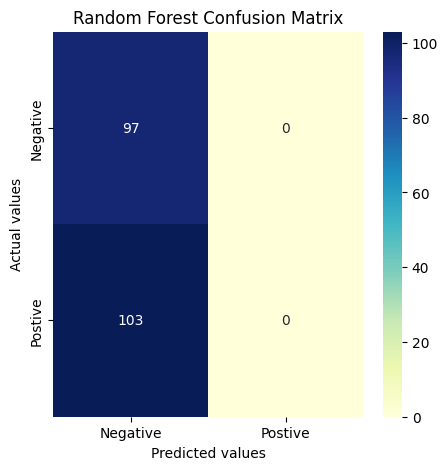

In [28]:
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="YlGnBu",xticklabels=["Negative","Postive"],yticklabels=["Negative","Postive"])
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [30]:
best_accuracy=0
n_estimators_val=5
print("Testing different n_estimators values...\n")
for i in np.arange(1,30,2):
  temp_model=RandomForestClassifier(n_estimators=i,random_state=42)
  temp_model.fit(X_train,y_train)
  temp_pred=temp_model.predict(X_test)
  score=accuracy_score(y_test,temp_pred)
  print("n_estimators:",i,"Accuracy:",round(score*100,2),"%")
  if score>best_accuracy:
    best_accuracy=score
    n_estimators_val=i
print("Best accuracy:",round(best_accuracy*100,2),"%")
print("Best n_estimators:",n_estimators_val)

Testing different n_estimators values...

n_estimators: 1 Accuracy: 48.5 %
n_estimators: 3 Accuracy: 48.5 %
n_estimators: 5 Accuracy: 48.5 %
n_estimators: 7 Accuracy: 48.5 %
n_estimators: 9 Accuracy: 48.5 %
n_estimators: 11 Accuracy: 48.5 %
n_estimators: 13 Accuracy: 48.5 %
n_estimators: 15 Accuracy: 48.5 %
n_estimators: 17 Accuracy: 48.5 %
n_estimators: 19 Accuracy: 48.5 %
n_estimators: 21 Accuracy: 48.5 %
n_estimators: 23 Accuracy: 48.5 %
n_estimators: 25 Accuracy: 48.5 %
n_estimators: 27 Accuracy: 48.5 %
n_estimators: 29 Accuracy: 48.5 %
Best accuracy: 48.5 %
Best n_estimators: 1


In [31]:
model=RandomForestClassifier(n_estimators=n_estimators_val,random_state=42)
model.fit(X_train,y_train)
print("Random Forest model trained successfully!")
print(model)

Random Forest model trained successfully!
RandomForestClassifier(n_estimators=np.int64(1), random_state=42)


In [41]:
def predict_sentiment(review):
  review=re.sub("[^a-zA-Z]","",review).lower()
  words=review.split()
  words=[w for w in words if w not in english_stopwords]
  words=[ps.stem(w) for w in words]
  review=" ".join(words)
  data=cv.transform([review]).toarray()
  return model.predict(data)[0]
sample_review="The food is really good here"
prediction=predict_sentiment(sample_review)
print("Sample Review:",sample_review)
if prediction == 1:
  print("This is a positive review")
else:
  print("This is a Negative review!")

Sample Review: The food is really good here
This is a Negative review!


In [39]:
sample_review="The food was absolutely awful"
prediction=predict_sentiment(sample_review)
print("Sample Review:",sample_review)
if prediction == 1:
  print("This is a positive review")
else:
  print("This is a Negative review!")

Sample Review: The food was absolutely awful
This is a Negative review!


In [42]:
final_predictions=model.predict(X_test)
final_accuracy=accuracy_score(y_test,final_predictions)
precision=precision_score(y_test,final_predictions)
recall=recall_score(y_test,final_predictions)
print("\n===================================")
print("FINAL RANDOM FOREST MODEL PERFORMANCE")
print("===================================")
print("Accuracy:",round(final_accuracy*100,2),"%")
print("Precision:",round(precision*100,2),"%")
print("Recall:",round(recall*100,2),"%")
print("Best n_estimators:",n_estimators_val)






FINAL RANDOM FOREST MODEL PERFORMANCE
Accuracy: 48.5 %
Precision: 0.0 %
Recall: 0.0 %
Best n_estimators: 1


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
